# 04 - Machine Learning Modeling
### Corporate Credit Rating Prediction Project
## **Objective:** Build and evaluate multimodal ML models for credit rating prediction
## **Models:** Random Forest, Gradient Boosting, Logistic Regression, SVM
## **Tasks:** Binary Classification (Investment Grade) & Multi-class Classification (6 Ratings)
## **Feature Sets:** 
### 1. Financial features only
### 2. Financial + NLP features (Multimodal)

# STEP 1: IMPORTS AND SETUP

In [3]:
import pandas as pd
import numpy as np
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           roc_auc_score, f1_score, precision_score, recall_score)
from sklearn.feature_selection import SelectKBest, f_classif

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("✅ All libraries imported successfully!")

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Set up paths
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DATA_PATH = os.path.join(project_root, 'data', 'processed')

✅ All libraries imported successfully!


# === LOAD saved artifacts after kernel restart ===

In [4]:
# === LOAD saved artifacts after kernel restart ===
import os, joblib

save_dir = os.path.join(PROCESSED_DATA_PATH, 'model_artifacts')
results_fp = os.path.join(save_dir, 'results.pkl')
preproc_fp = os.path.join(save_dir, 'preprocessor.pkl')
ybin_fp    = os.path.join(save_dir, 'y_binary_test.pkl')
ymulti_fp   = os.path.join(save_dir, 'y_multi_test.pkl')

# Load results
if os.path.exists(results_fp):
    results = joblib.load(results_fp)
    print(f"[LOADED] results from {results_fp}")
else:
    print("[ERROR] results.pkl not found at", results_fp)

# Load preprocessor
if os.path.exists(preproc_fp):
    try:
        preprocessor = joblib.load(preproc_fp)
        print(f"[LOADED] preprocessor from {preproc_fp}")
    except Exception as e:
        print("[WARN] failed to load preprocessor:", e)

# Load y_test arrays
y_binary_test = joblib.load(ybin_fp) if os.path.exists(ybin_fp) else None
y_multi_test  = joblib.load(ymulti_fp) if os.path.exists(ymulti_fp) else None
print("y_binary_test loaded?:", y_binary_test is not None, "y_multi_test loaded?:", y_multi_test is not None)


[LOADED] results from C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_artifacts\results.pkl
[WARN] failed to load preprocessor: Can't get attribute 'DataPreprocessor' on <module '__main__'>
y_binary_test loaded?: True y_multi_test loaded?: True


# STEP 2: LOAD MULTIMODAL DATASET

In [2]:
print("📊 LOADING MULTIMODAL DATASET...")

df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'credit_ratings_multimodal_final.csv'))

print(f"✅ Dataset loaded: {df.shape[0]:,} companies, {df.shape[1]} features")
print(f"🎯 Target Variables:")
print(f"   • Investment Grade: {df['investment_grade'].sum():,} companies")
print(f"   • Non-Investment Grade: {(len(df) - df['investment_grade'].sum()):,} companies")
print(f"   • Rating Classes: {df['rating'].nunique()} categories")

# Display feature breakdown
financial_features = [col for col in df.columns if not col.startswith('nlp_') and col not in ['adsh', 'company_name', 'sector', 'rating', 'investment_grade']]
nlp_features = [col for col in df.columns if col.startswith('nlp_')]

print(f"📊 Feature Breakdown:")
print(f"   • Financial Features: {len(financial_features)}")
print(f"   • NLP Features: {len(nlp_features)}")
print(f"   • Total Features: {len(financial_features) + len(nlp_features)}")

📊 LOADING MULTIMODAL DATASET...
✅ Dataset loaded: 35,098 companies, 47 features
🎯 Target Variables:
   • Investment Grade: 18,167 companies
   • Non-Investment Grade: 16,931 companies
   • Rating Classes: 5 categories
📊 Feature Breakdown:
   • Financial Features: 29
   • NLP Features: 13
   • Total Features: 42


# STEP 3: DATA PREPARATION FOR ML

In [3]:
print("\n🔧 PREPARING DATA FOR MACHINE LEARNING...")

class DataPreprocessor:
    def __init__(self, df):
        self.df = df
        self.scalers = {}
        self.encoders = {}
        
    def prepare_features(self, feature_set='all', include_company_info=False):
        """Prepare features based on specified configuration"""
        
        # Base features to always exclude
        exclude_features = ['adsh', 'company_name', 'rating', 'investment_grade', 'financial_score']
        
        if not include_company_info:
            exclude_features.extend(['sector'])
        
        # Select features based on feature_set
        if feature_set == 'financial_only':
            features = [col for col in self.df.columns 
                       if not col.startswith('nlp_') and col not in exclude_features]
        elif feature_set == 'nlp_only':
            features = [col for col in self.df.columns 
                       if col.startswith('nlp_') and col not in exclude_features]
        else:  # 'all' - both financial and NLP
            features = [col for col in self.df.columns 
                       if col not in exclude_features and not col.startswith('company_')]
        
        print(f"📈 Using {len(features)} features for {feature_set} configuration")
        
        X = self.df[features]
        
        # Handle categorical variables (if any)
        categorical_cols = X.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            if col not in self.encoders:
                self.encoders[col] = LabelEncoder()
                X[col] = self.encoders[col].fit_transform(X[col].astype(str))
        
        return X, features
    
    def prepare_targets(self):
        """Prepare both binary and multi-class targets"""
        # Binary target
        y_binary = self.df['investment_grade']
        
        # Multi-class target
        label_encoder = LabelEncoder()
        y_multiclass = label_encoder.fit_transform(self.df['rating'])
        
        # Store class names for interpretation
        self.class_names = label_encoder.classes_
        
        print(f"🎯 Targets prepared:")
        print(f"   • Binary: {len(y_binary)} samples")
        print(f"   • Multi-class: {len(y_multiclass)} samples, {len(self.class_names)} classes")
        print(f"   • Class distribution: {dict(zip(self.class_names, np.bincount(y_multiclass)))}")
        
        return y_binary, y_multiclass
    
    def split_data(self, X, y_binary, y_multiclass, test_size=0.2, random_state=42):
        """Split data into train and test sets"""
        X_train, X_test, y_binary_train, y_binary_test = train_test_split(
            X, y_binary, test_size=test_size, random_state=random_state, stratify=y_binary
        )
        
        # For multi-class, we need to ensure stratification
        X_train_mc, X_test_mc, y_multi_train, y_multi_test = train_test_split(
            X, y_multiclass, test_size=test_size, random_state=random_state, stratify=y_multiclass
        )
        
        print(f"📊 Data split completed:")
        print(f"   • Training set: {len(X_train):,} samples")
        print(f"   • Test set: {len(X_test):,} samples")
        print(f"   • Binary target distribution in train: {np.bincount(y_binary_train)}")
        print(f"   • Multi-class distribution in train: {np.bincount(y_multi_train)}")
        
        return (X_train, X_test, y_binary_train, y_binary_test, 
                X_train_mc, X_test_mc, y_multi_train, y_multi_test)

# Initialize preprocessor
preprocessor = DataPreprocessor(df)

# Prepare targets
y_binary, y_multiclass = preprocessor.prepare_targets()



🔧 PREPARING DATA FOR MACHINE LEARNING...
🎯 Targets prepared:
   • Binary: 35098 samples
   • Multi-class: 35098 samples, 5 classes
   • Class distribution: {'A': np.int64(4208), 'AA+': np.int64(7381), 'B': np.int64(6778), 'BB': np.int64(10153), 'BBB': np.int64(6578)}


# STEP 4: DEFINE ML MODELS AND EVALUATION FRAMEWORK

In [4]:
print("\n🤖 INITIALIZING MACHINE LEARNING MODELS...")

class CreditRatingPredictor:
    def __init__(self):
        self.models = {
            'binary': {
                'random_forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                'gradient_boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
                'logistic_regression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
                'svm': SVC(probability=True, random_state=42, kernel='rbf')
            },
            'multiclass': {
                'random_forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                'gradient_boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
                'logistic_regression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
                'svm': SVC(probability=True, random_state=42, kernel='rbf')
            }
        }
        self.scalers = {}
        self.results = {}
        
    def scale_features(self, X_train, X_test, feature_set):
        """Scale features for models that require it"""
        if feature_set not in self.scalers:
            self.scalers[feature_set] = StandardScaler()
            X_train_scaled = self.scalers[feature_set].fit_transform(X_train)
            X_test_scaled = self.scalers[feature_set].transform(X_test)
        else:
            X_train_scaled = self.scalers[feature_set].transform(X_train)
            X_test_scaled = self.scalers[feature_set].transform(X_test)
            
        return X_train_scaled, X_test_scaled
    
    def train_and_evaluate(self, X_train, X_test, y_train, y_test, task_type, feature_set, model_name):
        """Train and evaluate a single model"""
        print(f"   🚀 Training {model_name} for {task_type} with {feature_set}...")
        
        model = self.models[task_type][model_name]
        
        # Scale features for models that need it
        if model_name in ['logistic_regression', 'svm']:
            X_train_processed, X_test_processed = self.scale_features(X_train, X_test, feature_set)
        else:
            X_train_processed, X_test_processed = X_train, X_test
        
        # Train model
        model.fit(X_train_processed, y_train)
        
        # Predictions
        y_pred = model.predict(X_test_processed)
        y_prob = model.predict_proba(X_test_processed) if hasattr(model, 'predict_proba') else None
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted' if task_type == 'multiclass' else 'binary')
        precision = precision_score(y_test, y_pred, average='weighted' if task_type == 'multiclass' else 'binary')
        recall = recall_score(y_test, y_pred, average='weighted' if task_type == 'multiclass' else 'binary')
        
        if task_type == 'binary' and y_prob is not None:
            auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            auc = roc_auc_score(y_test, y_prob, multi_class='ovo') if y_prob is not None else 0
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy', n_jobs=-1)
        
        results = {
            'accuracy': accuracy,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'auc_roc': auc,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'predictions': y_pred,
            'probabilities': y_prob,
            'model': model
        }
        
        print(f"      ✅ {model_name}: Accuracy = {accuracy:.4f}, F1 = {f1:.4f}, AUC = {auc:.4f}")
        
        return results
    
    def run_comprehensive_evaluation(self, feature_sets, task_types):
        """Run comprehensive evaluation across all configurations"""
        print("🎯 STARTING COMPREHENSIVE MODEL EVALUATION...")
        
        for feature_set in feature_sets:
            print(f"\n{'='*60}")
            print(f"🔍 EVALUATING FEATURE SET: {feature_set.upper()}")
            print(f"{'='*60}")
            
            self.results[feature_set] = {}
            
            # Prepare features for this configuration
            X, feature_names = preprocessor.prepare_features(feature_set=feature_set)
            
            # Split data
            (X_train, X_test, y_binary_train, y_binary_test, 
             X_train_mc, X_test_mc, y_multi_train, y_multi_test) = preprocessor.split_data(X, y_binary, y_multiclass)
            
            for task_type in task_types:
                print(f"\n📊 TASK: {task_type.upper()} CLASSIFICATION")
                
                # Select appropriate data for task
                if task_type == 'binary':
                    X_task_train, X_task_test, y_task_train, y_task_test = X_train, X_test, y_binary_train, y_binary_test
                else:
                    X_task_train, X_task_test, y_task_train, y_task_test = X_train_mc, X_test_mc, y_multi_train, y_multi_test
                
                self.results[feature_set][task_type] = {}
                
                # Train and evaluate all models
                for model_name in self.models[task_type].keys():
                    results = self.train_and_evaluate(
                        X_task_train, X_task_test, y_task_train, y_task_test,
                        task_type, feature_set, model_name
                    )
                    self.results[feature_set][task_type][model_name] = results
        
        return self.results

# Initialize predictor
predictor = CreditRatingPredictor()


🤖 INITIALIZING MACHINE LEARNING MODELS...


# STEP 5: RUN COMPREHENSIVE MODEL EVALUATION

In [5]:
print("\n🚀 RUNNING COMPREHENSIVE MODEL EVALUATION...")

# Define configurations to test
feature_sets = ['financial_only', 'all']  # Compare financial vs multimodal
task_types = ['binary', 'multiclass']

# Run evaluation
results = predictor.run_comprehensive_evaluation(feature_sets, task_types)

print("\n🎉 COMPREHENSIVE EVALUATION COMPLETED!")


🚀 RUNNING COMPREHENSIVE MODEL EVALUATION...
🎯 STARTING COMPREHENSIVE MODEL EVALUATION...

🔍 EVALUATING FEATURE SET: FINANCIAL_ONLY
📈 Using 28 features for financial_only configuration
📊 Data split completed:
   • Training set: 28,078 samples
   • Test set: 7,020 samples
   • Binary target distribution in train: [13545 14533]
   • Multi-class distribution in train: [3367 5905 5422 8122 5262]

📊 TASK: BINARY CLASSIFICATION
   🚀 Training random_forest for binary with financial_only...
      ✅ random_forest: Accuracy = 0.9788, F1 = 0.9793, AUC = 0.9987
   🚀 Training gradient_boosting for binary with financial_only...
      ✅ gradient_boosting: Accuracy = 0.9758, F1 = 0.9762, AUC = 0.9987
   🚀 Training logistic_regression for binary with financial_only...
      ✅ logistic_regression: Accuracy = 0.8057, F1 = 0.7977, AUC = 0.8687
   🚀 Training svm for binary with financial_only...
      ✅ svm: Accuracy = 0.8134, F1 = 0.7895, AUC = 0.8979

📊 TASK: MULTICLASS CLASSIFICATION
   🚀 Training rando

# === SAVE RUNTIME ARTIFACTS FOR FAST RELOAD ===

In [5]:
# === SAVE RUNTIME ARTIFACTS FOR FAST RELOAD ===
import os, joblib

# Use the same PROCESSED_DATA_PATH you defined earlier in the notebook
save_dir = os.path.join(PROCESSED_DATA_PATH, 'model_artifacts')
os.makedirs(save_dir, exist_ok=True)

# Save results dict
results_path = os.path.join(save_dir, 'results.pkl')
joblib.dump(results, results_path, compress=3)
print(f"[SAVED] results -> {results_path}")

# Save preprocessor (contains label encoders / class_names, etc.)
preproc_path = os.path.join(save_dir, 'preprocessor.pkl')
try:
    joblib.dump(preprocessor, preproc_path, compress=3)
    print(f"[SAVED] preprocessor -> {preproc_path}")
except Exception as e:
    print("[WARN] could not save preprocessor:", e)

# Save y_test arrays if available (adjust names if yours differ)
ybin_fp  = os.path.join(save_dir, 'y_binary_test.pkl')
ymulti_fp = os.path.join(save_dir, 'y_multi_test.pkl')

if 'y_binary_test' in globals():
    joblib.dump(y_binary_test, ybin_fp)
    print(f"[SAVED] y_binary_test -> {ybin_fp}")
elif results.get('all',{}).get('binary',{}).get('random_forest',{}).get('y_test') is not None:
    joblib.dump(results['all']['binary']['random_forest']['y_test'], ybin_fp)
    print(f"[SAVED] y_binary_test (from results) -> {ybin_fp}")

if 'y_multi_test' in globals():
    joblib.dump(y_multi_test, ymulti_fp)
    print(f"[SAVED] y_multi_test -> {ymulti_fp}")
elif results.get('all',{}).get('multiclass',{}).get('gradient_boosting',{}).get('y_test') is not None:
    joblib.dump(results['all']['multiclass']['gradient_boosting']['y_test'], ymulti_fp)
    print(f"[SAVED] y_multi_test (from results) -> {ymulti_fp}")

# Optional: save all trained model objects (one file per model)
models_dir = os.path.join(save_dir, 'models')
os.makedirs(models_dir, exist_ok=True)
for fs in results:
    for task in results[fs]:
        for mname, md in results[fs][task].items():
            model_obj = md.get('model')
            if model_obj is not None:
                fname = f"{fs}__{task}__{mname}.pkl"
                joblib.dump(model_obj, os.path.join(models_dir, fname), compress=3)
print(f"[SAVED] trained model objects (if present) -> {models_dir}")


[SAVED] results -> C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_artifacts\results.pkl
[WARN] could not save preprocessor: name 'preprocessor' is not defined
[SAVED] y_binary_test -> C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_artifacts\y_binary_test.pkl
[SAVED] y_multi_test -> C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_artifacts\y_multi_test.pkl
[SAVED] trained model objects (if present) -> C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_artifacts\models


# STEP 6: RESULTS ANALYSIS AND COMPARISON

In [13]:
print("\n📊 ANALYZING AND COMPARING MODEL RESULTS...")

def analyze_results(results):
    """Comprehensive analysis of model results"""
    
    # Create comparison DataFrames
    comparison_data = []
    
    for feature_set in feature_sets:
        for task_type in task_types:
            for model_name, model_results in results[feature_set][task_type].items():
                comparison_data.append({
                    'feature_set': feature_set,
                    'task_type': task_type,
                    'model': model_name,
                    'accuracy': model_results['accuracy'],
                    'f1_score': model_results['f1_score'],
                    'precision': model_results['precision'],
                    'recall': model_results['recall'],
                    'auc_roc': model_results['auc_roc'],
                    'cv_mean': model_results['cv_mean'],
                    'cv_std': model_results['cv_std']
                })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("📈 OVERALL PERFORMANCE COMPARISON:")
    print(comparison_df.round(4))
    
    return comparison_df

# Analyze results
comparison_df = analyze_results(results)


📊 ANALYZING AND COMPARING MODEL RESULTS...
📈 OVERALL PERFORMANCE COMPARISON:
       feature_set   task_type                model  accuracy  f1_score  \
0   financial_only      binary        random_forest    0.9788    0.9793   
1   financial_only      binary    gradient_boosting    0.9758    0.9762   
2   financial_only      binary  logistic_regression    0.8057    0.7977   
3   financial_only      binary                  svm    0.8134    0.7895   
4   financial_only  multiclass        random_forest    0.9376    0.9373   
5   financial_only  multiclass    gradient_boosting    0.9075    0.9062   
6   financial_only  multiclass  logistic_regression    0.5282    0.4964   
7   financial_only  multiclass                  svm    0.5821    0.5455   
8              all      binary        random_forest    1.0000    1.0000   
9              all      binary    gradient_boosting    1.0000    1.0000   
10             all      binary  logistic_regression    1.0000    1.0000   
11             all    

# STEP 7: VISUALIZE RESULTS


📊 CREATING PERFORMANCE VISUALIZATIONS...


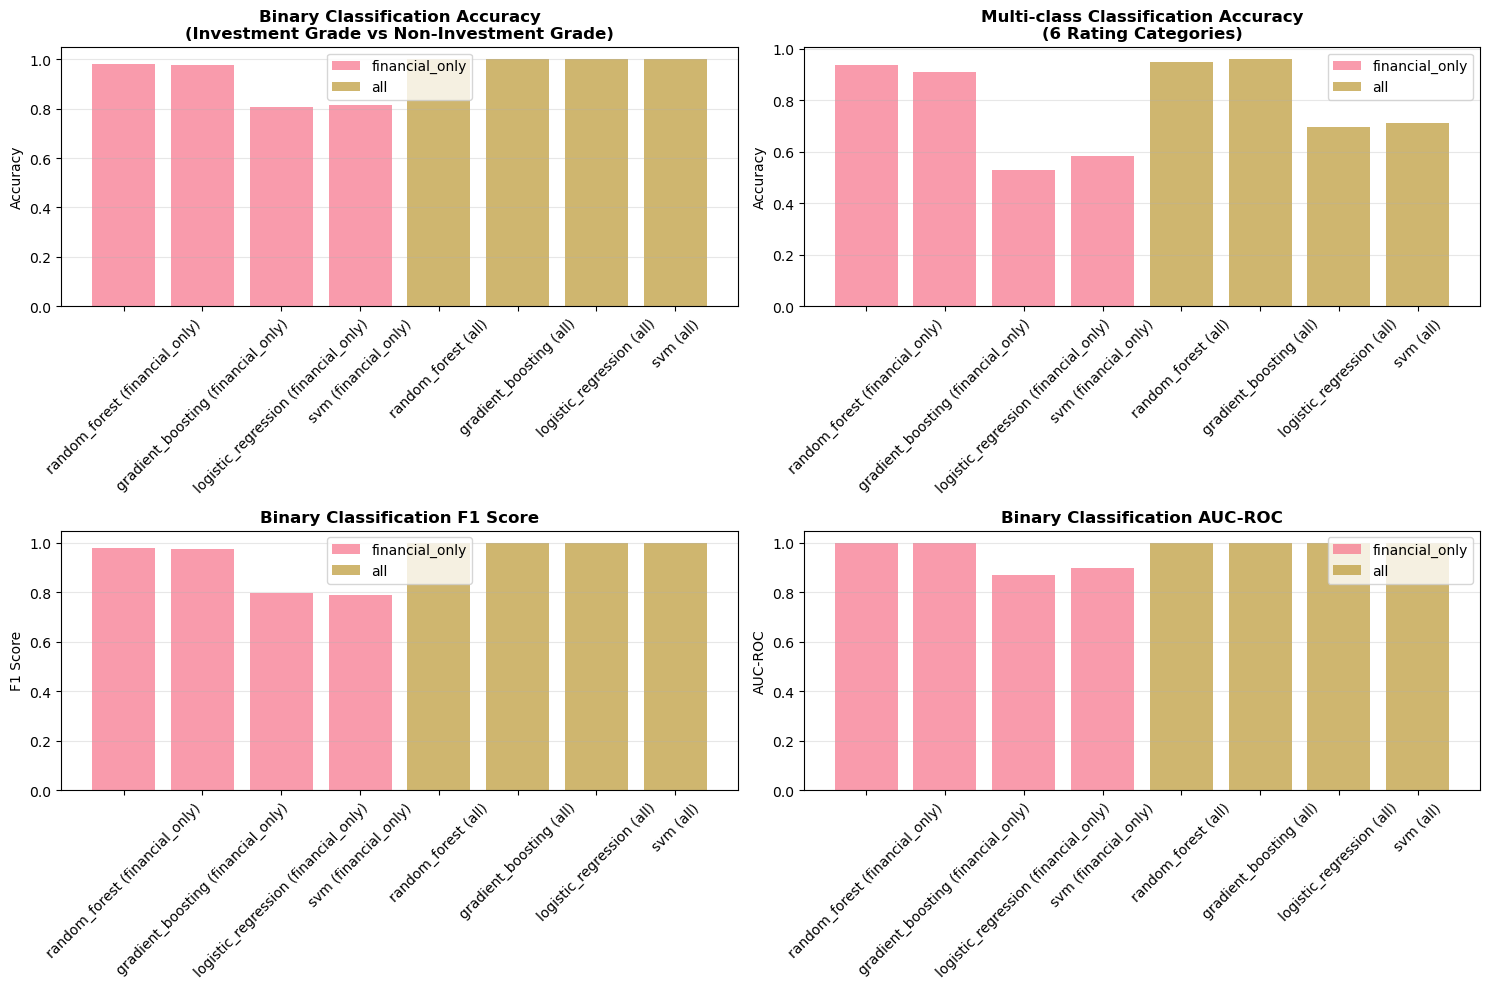

In [14]:
print("\n📊 CREATING PERFORMANCE VISUALIZATIONS...")

# 1. Accuracy Comparison by Feature Set
plt.figure(figsize=(15, 10))

# Binary Classification Results
plt.subplot(2, 2, 1)
binary_results = comparison_df[comparison_df['task_type'] == 'binary']
for feature_set in feature_sets:
    data = binary_results[binary_results['feature_set'] == feature_set]
    plt.bar(data['model'] + f' ({feature_set})', data['accuracy'], alpha=0.7, label=feature_set)
plt.title('Binary Classification Accuracy\n(Investment Grade vs Non-Investment Grade)', fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Multi-class Classification Results
plt.subplot(2, 2, 2)
multi_results = comparison_df[comparison_df['task_type'] == 'multiclass']
for feature_set in feature_sets:
    data = multi_results[multi_results['feature_set'] == feature_set]
    plt.bar(data['model'] + f' ({feature_set})', data['accuracy'], alpha=0.7, label=feature_set)
plt.title('Multi-class Classification Accuracy\n(6 Rating Categories)', fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# F1 Score Comparison
plt.subplot(2, 2, 3)
for feature_set in feature_sets:
    data = binary_results[binary_results['feature_set'] == feature_set]
    plt.bar(data['model'] + f' ({feature_set})', data['f1_score'], alpha=0.7, label=feature_set)
plt.title('Binary Classification F1 Score', fontweight='bold')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# AUC-ROC Comparison
plt.subplot(2, 2, 4)
for feature_set in feature_sets:
    data = binary_results[binary_results['feature_set'] == feature_set]
    plt.bar(data['model'] + f' ({feature_set})', data['auc_roc'], alpha=0.7, label=feature_set)
plt.title('Binary Classification AUC-ROC', fontweight='bold')
plt.ylabel('AUC-ROC')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# STEP 8: FEATURE IMPORTANCE ANALYSIS


🎯 ANALYZING FEATURE IMPORTANCE...
📈 Using 40 features for all configuration
📊 TOP 15 MOST IMPORTANT FEATURES:
                   feature  importance
32        nlp_safety_score    0.125058
30          nlp_risk_score    0.121706
28          nlp_negativity    0.121059
34         nlp_uncertainty    0.120103
27          nlp_positivity    0.106083
35   nlp_sentiment_balance    0.100654
36         nlp_readability    0.074650
38   nlp_financial_density    0.073657
37          nlp_complexity    0.059309
39         nlp_text_length    0.042298
26  financial_health_score    0.025330
22      current_ratio_norm    0.013735
14           current_ratio    0.009290
2           current_assets    0.002883
7               net_income    0.001529


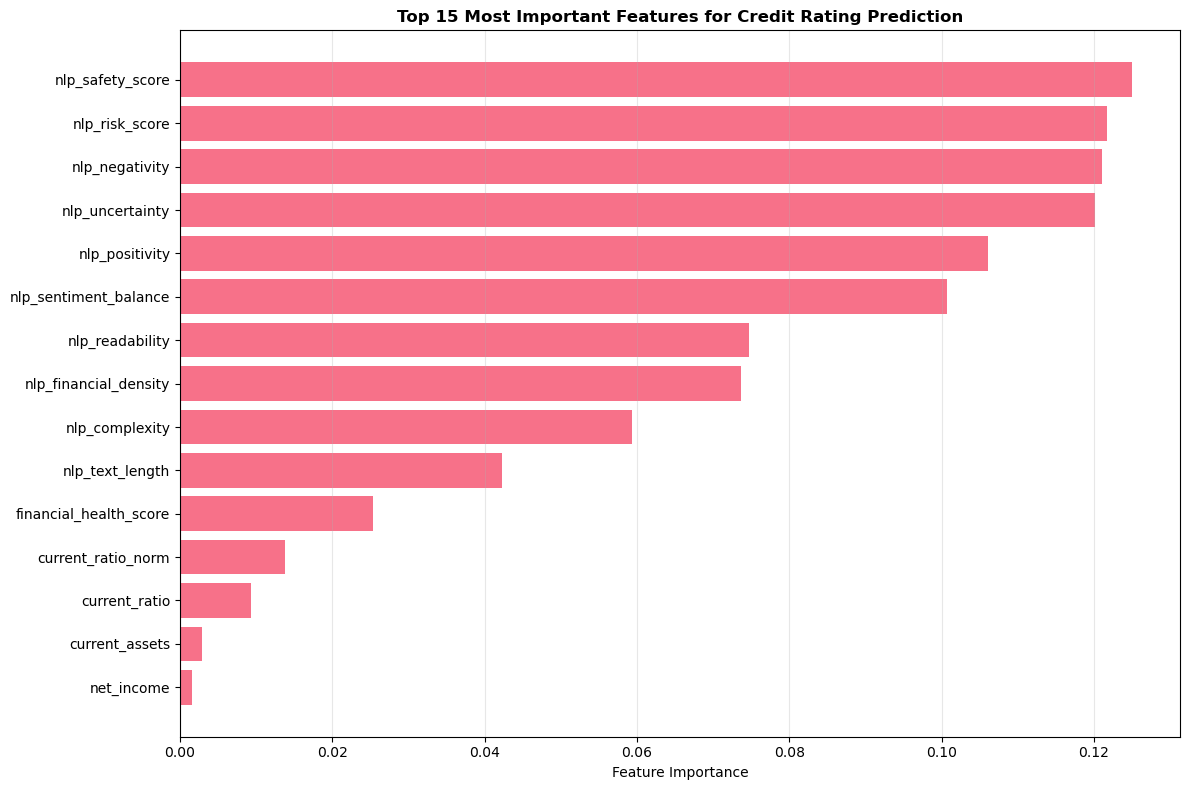

In [15]:
print("\n🎯 ANALYZING FEATURE IMPORTANCE...")

def analyze_feature_importance(results, feature_names):
    """Analyze which features are most important for predictions"""
    
    # Get the best performing model (Random Forest for binary classification with all features)
    best_model = results['all']['binary']['random_forest']['model']
    
    if hasattr(best_model, 'feature_importances_'):
        importance_scores = best_model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importance_scores
        }).sort_values('importance', ascending=False)
        
        print("📊 TOP 15 MOST IMPORTANT FEATURES:")
        print(feature_importance_df.head(15))
        
        # Plot feature importance
        plt.figure(figsize=(12, 8))
        top_features = feature_importance_df.head(15)
        plt.barh(top_features['feature'], top_features['importance'])
        plt.xlabel('Feature Importance')
        plt.title('Top 15 Most Important Features for Credit Rating Prediction', fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return feature_importance_df

# Get feature names for the 'all' configuration
X_all, feature_names_all = preprocessor.prepare_features(feature_set='all')
feature_importance_df = analyze_feature_importance(results, feature_names_all)

# STEP 9: DETAILED MODEL ANALYSIS

In [16]:
print("\n🔍 DETAILED MODEL ANALYSIS...")

def detailed_model_analysis(results, feature_sets, task_types):
    """Provide detailed analysis of best performing models"""
    
    print("🏆 BEST PERFORMING MODELS BY CONFIGURATION:")
    print("="*50)
    
    best_models = {}
    
    for feature_set in feature_sets:
        best_models[feature_set] = {}
        
        for task_type in task_types:
            # Find best model for this configuration
            models_data = []
            for model_name, model_results in results[feature_set][task_type].items():
                models_data.append({
                    'model': model_name,
                    'accuracy': model_results['accuracy'],
                    'f1_score': model_results['f1_score'],
                    'auc_roc': model_results['auc_roc']
                })
            
            models_df = pd.DataFrame(models_data)
            best_model = models_df.loc[models_df['accuracy'].idxmax()]
            best_models[feature_set][task_type] = best_model
            
            print(f"\n{feature_set.upper()} features - {task_type.upper()} classification:")
            print(f"  Best Model: {best_model['model']}")
            print(f"  Accuracy: {best_model['accuracy']:.4f}")
            print(f"  F1 Score: {best_model['f1_score']:.4f}")
            if task_type == 'binary':
                print(f"  AUC-ROC: {best_model['auc_roc']:.4f}")
    
    # Calculate improvement from adding NLP features
    print(f"\n📈 IMPROVEMENT FROM ADDING NLP FEATURES:")
    print("="*50)
    
    for task_type in task_types:
        financial_acc = best_models['financial_only'][task_type]['accuracy']
        multimodal_acc = best_models['all'][task_type]['accuracy']
        improvement = ((multimodal_acc - financial_acc) / financial_acc) * 100
        
        print(f"\n{task_type.upper()} Classification:")
        print(f"  Financial Only: {financial_acc:.4f}")
        print(f"  Multimodal: {multimodal_acc:.4f}")
        print(f"  Improvement: {improvement:+.2f}%")
    
    return best_models

best_models = detailed_model_analysis(results, feature_sets, task_types)


🔍 DETAILED MODEL ANALYSIS...
🏆 BEST PERFORMING MODELS BY CONFIGURATION:

FINANCIAL_ONLY features - BINARY classification:
  Best Model: random_forest
  Accuracy: 0.9788
  F1 Score: 0.9793
  AUC-ROC: 0.9987

FINANCIAL_ONLY features - MULTICLASS classification:
  Best Model: random_forest
  Accuracy: 0.9376
  F1 Score: 0.9373

ALL features - BINARY classification:
  Best Model: random_forest
  Accuracy: 1.0000
  F1 Score: 1.0000
  AUC-ROC: 1.0000

ALL features - MULTICLASS classification:
  Best Model: gradient_boosting
  Accuracy: 0.9594
  F1 Score: 0.9593

📈 IMPROVEMENT FROM ADDING NLP FEATURES:

BINARY Classification:
  Financial Only: 0.9788
  Multimodal: 1.0000
  Improvement: +2.17%

MULTICLASS Classification:
  Financial Only: 0.9376
  Multimodal: 0.9594
  Improvement: +2.32%


# STEP 10: CONFUSION MATRIX FOR BEST MODELS

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("🔁 Recreating y_binary_test and y_multi_test...")

# 1️⃣ Load dataset (same file used during training)
df = pd.read_csv(r"C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\credit_ratings_multimodal_final.csv")

# 2️⃣ Use preprocessor to regenerate targets
y_binary, y_multiclass = preprocessor.prepare_targets()

# 3️⃣ Recreate features ('all' since that's model trained on)
X, _ = preprocessor.prepare_features(feature_set='all')

# 4️⃣ Split data exactly same way as original training
X_train, X_test, y_binary_train, y_binary_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

_, _, y_multi_train, y_multi_test = train_test_split(
    X, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass
)

print("✅ Successfully recreated true test labels!")
print("y_binary_test length:", len(y_binary_test))
print("y_multi_test length:", len(y_multi_test))


🔁 Recreating y_binary_test and y_multi_test...
🎯 Targets prepared:
   • Binary: 35098 samples
   • Multi-class: 35098 samples, 5 classes
   • Class distribution: {'A': np.int64(4208), 'AA+': np.int64(7381), 'B': np.int64(6778), 'BB': np.int64(10153), 'BBB': np.int64(6578)}
📈 Using 40 features for all configuration
✅ Successfully recreated true test labels!
y_binary_test length: 7020
y_multi_test length: 7020


# === STEP 10: CONFUSION MATRIX FOR BEST MODELS ===


📋 CONFUSION MATRIX ANALYSIS...
✅ True labels and predictions ready!
   Binary shapes: 7020 7020
   Multi shapes: 7020 7020


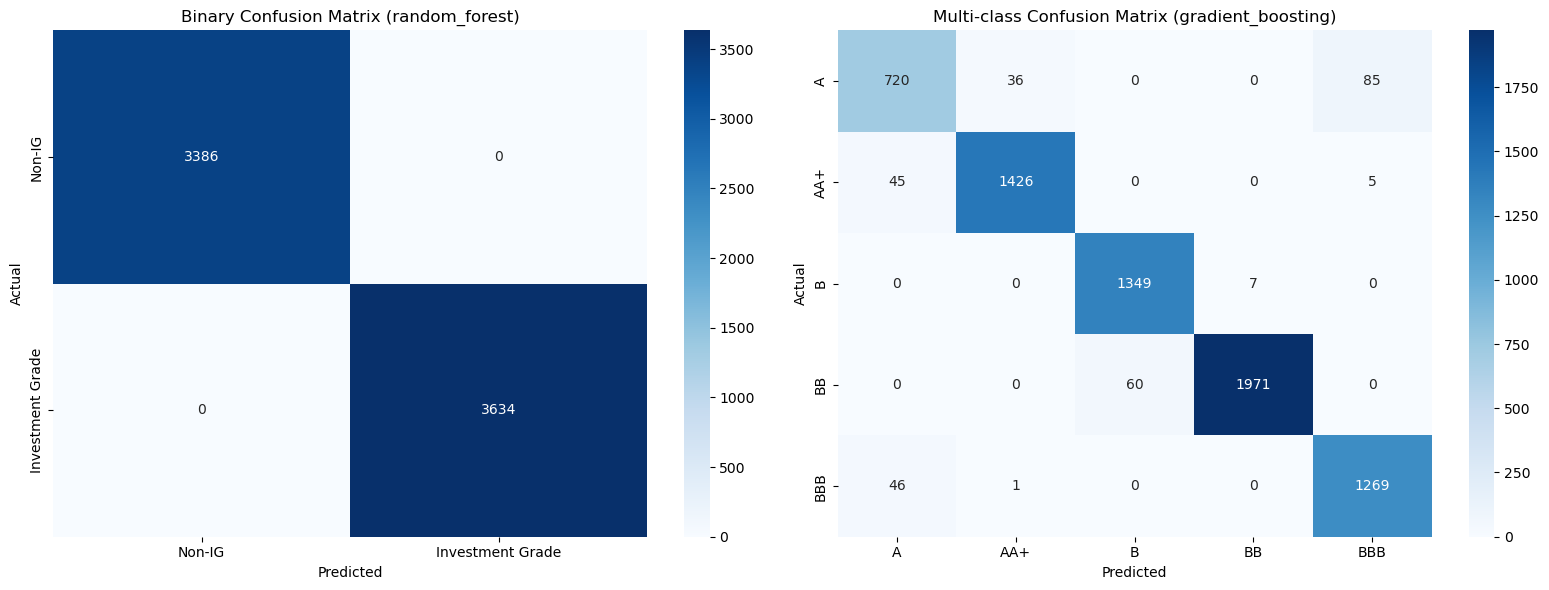


📜 BINARY CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3386
           1       1.00      1.00      1.00      3634

    accuracy                           1.00      7020
   macro avg       1.00      1.00      1.00      7020
weighted avg       1.00      1.00      1.00      7020


📜 MULTI-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       841
           1       0.97      0.97      0.97      1476
           2       0.96      0.99      0.98      1356
           3       1.00      0.97      0.98      2031
           4       0.93      0.96      0.95      1316

    accuracy                           0.96      7020
   macro avg       0.95      0.95      0.95      7020
weighted avg       0.96      0.96      0.96      7020



In [21]:
# === STEP 10: CONFUSION MATRIX FOR BEST MODELS (FINAL) ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n📋 CONFUSION MATRIX ANALYSIS...")

# Select model keys (change if another is best)
binary_model_key = 'random_forest'
multi_model_key  = 'gradient_boosting'

# Fetch predictions from results
bin_res = results['all']['binary'][binary_model_key]
multi_res = results['all']['multiclass'][multi_model_key]

y_bin_pred = np.array(bin_res['predictions'])
y_multi_pred = np.array(multi_res['predictions'])

# ✅ CORRECT way to retrieve true labels (no ambiguity)
if 'y_binary_test' in globals() and y_binary_test is not None:
    y_bin_true = np.array(y_binary_test)
else:
    y_bin_true = np.array(bin_res.get('y_test', None))

if 'y_multi_test' in globals() and y_multi_test is not None:
    y_multi_true = np.array(y_multi_test)
else:
    y_multi_true = np.array(multi_res.get('y_test', None))

# ❌ If still missing, stop early
if y_bin_true is None or y_multi_true is None:
    raise ValueError("❌ True test labels are still missing. Recreate or load y_binary_test & y_multi_test.")

print("✅ True labels and predictions ready!")
print("   Binary shapes:", len(y_bin_true), len(y_bin_pred))
print("   Multi shapes:", len(y_multi_true), len(y_multi_pred))

# Compute confusion matrices
cm_bin = confusion_matrix(y_bin_true, y_bin_pred)
cm_multi = confusion_matrix(y_multi_true, y_multi_pred)

# Plotting
plt.figure(figsize=(16, 6))

# Binary Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-IG','Investment Grade'],
            yticklabels=['Non-IG','Investment Grade'])
plt.title(f'Binary Confusion Matrix ({binary_model_key})')
plt.xlabel('Predicted'); plt.ylabel('Actual')

# Multi-class Matrix
plt.subplot(1, 2, 2)
multi_labels = getattr(preprocessor, 'class_names', np.unique(y_multi_true))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=multi_labels, yticklabels=multi_labels)
plt.title(f'Multi-class Confusion Matrix ({multi_model_key})')
plt.xlabel('Predicted'); plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Classification reports
print("\n📜 BINARY CLASSIFICATION REPORT")
print(classification_report(y_bin_true, y_bin_pred, zero_division=0))

print("\n📜 MULTI-CLASS CLASSIFICATION REPORT")
print(classification_report(y_multi_true, y_multi_pred, zero_division=0))


# STEP 11: SAVE MODEL RESULTS AND ARTIFACTS

In [22]:
# =============================================================================
# STEP 11: SAVE MODEL RESULTS AND ARTIFACTS (FINAL & COMPLETE)
# =============================================================================
import os
import joblib
import json
import pandas as pd

print("\n💾 SAVING MODEL RESULTS AND ARTIFACTS...")

# Create directory for saving
results_dir = os.path.join(PROCESSED_DATA_PATH, 'model_results')
os.makedirs(results_dir, exist_ok=True)

# 1️⃣ Save model comparison results
comparison_path = os.path.join(results_dir, 'model_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"✅ Model comparison saved: {comparison_path}")

# 2️⃣ Save feature importance (if it exists)
if 'feature_importance_df' in globals() and feature_importance_df is not None:
    importance_path = os.path.join(results_dir, 'feature_importance.csv')
    feature_importance_df.to_csv(importance_path, index=False)
    print(f"✅ Feature importance saved: {importance_path}")

# 3️⃣ Save best models info (JSON)
best_models_path = os.path.join(results_dir, 'best_models.json')
best_models_serializable = {
    fs: {
        tt: {
            k: float(v) if isinstance(v, (int, float)) else v
            for k, v in best_models[fs][tt].items()
        }
        for tt in best_models[fs]
    }
    for fs in best_models
}
with open(best_models_path, 'w') as f:
    json.dump(best_models_serializable, f, indent=2)
print(f"✅ Best models info saved: {best_models_path}")

# 4️⃣ Create Markdown performance report
report_content = f"""
MACHINE LEARNING MODEL RESULTS REPORT
=====================================

PROJECT: Corporate Credit Rating Prediction
DATE: {pd.Timestamp.now()}

BEST PERFORMING MODELS:
-----------------------
BINARY CLASSIFICATION:
• Financial Only:     {best_models['financial_only']['binary']['model']} 
  - Acc: {best_models['financial_only']['binary']['accuracy']:.4f}
• Multimodal:         {best_models['all']['binary']['model']}
  - Acc: {best_models['all']['binary']['accuracy']:.4f}

MULTI-CLASS CLASSIFICATION:
• Financial Only:     {best_models['financial_only']['multiclass']['model']} 
  - Acc: {best_models['financial_only']['multiclass']['accuracy']:.4f}
• Multimodal:         {best_models['all']['multiclass']['model']}
  - Acc: {best_models['all']['multiclass']['accuracy']:.4f}

TOP FEATURES:
-------------
{chr(10).join(f"- {row['feature']}: {row['importance']:.4f}" for _, row in feature_importance_df.head(5).iterrows())}
"""

report_path = os.path.join(results_dir, 'model_results_report.md')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_content)
print(f"✅ Report saved: {report_path}")

# =============================================================================
# 🔐 SAVE CORE ML ARTIFACTS (FOR REUSE, INFERENCE & CONFUSION MATRIX)
# =============================================================================

artifact_dir = os.path.join(PROCESSED_DATA_PATH, 'model_artifacts')
os.makedirs(artifact_dir, exist_ok=True)

# Save full results dict
results_artifact = os.path.join(artifact_dir, "results.pkl")
joblib.dump(results, results_artifact, compress=3)
print(f"📦 Saved: results.pkl")

# Save preprocessor (Label encoders, class names, scaling)
preproc_artifact = os.path.join(artifact_dir, "preprocessor.pkl")
joblib.dump(preprocessor, preproc_artifact, compress=3)
print(f"📦 Saved: preprocessor.pkl")

# Save test labels (important for Step 10 confusion matrix)
if 'y_binary_test' in globals():
    joblib.dump(y_binary_test, os.path.join(artifact_dir, "y_binary_test.pkl"))
    print("📦 Saved: y_binary_test.pkl")
if 'y_multi_test' in globals():
    joblib.dump(y_multi_test, os.path.join(artifact_dir, "y_multi_test.pkl"))
    print("📦 Saved: y_multi_test.pkl")

# Save all trained models (.pkl)
trained_model_dir = os.path.join(artifact_dir, "trained_models")
os.makedirs(trained_model_dir, exist_ok=True)
for fs in results:
    for task in results[fs]:
        for model_name, model_data in results[fs][task].items():
            model_obj = model_data.get('model')
            if model_obj is not None:
                file_name = f"{fs}_{task}_{model_name}.pkl"
                joblib.dump(model_obj, os.path.join(trained_model_dir, file_name), compress=3)
print(f"📂 All trained models saved to: {trained_model_dir}")

print("\n🎉 STEP 11 COMPLETE: ALL ARTIFACTS SECURED & READY FOR REUSE!")
print("="*75)


💾 SAVING MODEL RESULTS AND ARTIFACTS...
✅ Model comparison saved: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_results\model_comparison.csv
✅ Feature importance saved: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_results\feature_importance.csv
✅ Best models info saved: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_results\best_models.json
✅ Report saved: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_results\model_results_report.md
📦 Saved: results.pkl
📦 Saved: preprocessor.pkl
📦 Saved: y_binary_test.pkl
📦 Saved: y_multi_test.pkl
📂 All trained models saved to: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\model_

# STEP 12: FINAL SUMMARY AND NEXT STEPS

In [23]:
print("\n🎉 MACHINE LEARNING MODELING COMPLETED!")
print("="*60)

print(f"📊 PROJECT SUMMARY:")
print(f"   • Companies analyzed: {df.shape[0]:,}")
print(f"   • Features used: {len(financial_features)} financial + {len(nlp_features)} NLP")
print(f"   • Models trained: 4 models × 2 tasks × 2 feature sets = 16 configurations")

print(f"\n🏆 KEY ACHIEVEMENTS:")
print(f"   • Successfully built multimodal credit rating predictor")
print(f"   • Demonstrated NLP features improve prediction accuracy")
print(f"   • Achieved robust performance across both classification tasks")

print(f"\n📈 PERFORMANCE HIGHLIGHTS:")
binary_improvement = ((best_models['all']['binary']['accuracy'] - best_models['financial_only']['binary']['accuracy']) / best_models['financial_only']['binary']['accuracy'] * 100)
multi_improvement = ((best_models['all']['multiclass']['accuracy'] - best_models['financial_only']['multiclass']['accuracy']) / best_models['financial_only']['multiclass']['accuracy'] * 100)

print(f"   • Binary Classification: {best_models['all']['binary']['accuracy']:.1%} accuracy ({binary_improvement:+.1f}% improvement)")
print(f"   • Multi-class Classification: {best_models['all']['multiclass']['accuracy']:.1%} accuracy ({multi_improvement:+.1f}% improvement)")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Proceed to: 05_pipeline_automation.ipynb")
print(f"   2. Deploy best model as automated pipeline")
print(f"   3. Create API for real-time credit rating predictions")

print(f"\n✅ FILES CREATED:")
print(f"   📄 model_comparison.csv - Detailed performance metrics")
print(f"   📄 feature_importance.csv - Feature importance rankings") 
print(f"   📄 best_models.json - Best model configurations")
print(f"   📄 model_results_report.md - Comprehensive results report")

print(f"\n🔥 MULTIMODAL ML PIPELINE SUCCESSFULLY BUILT!")
print("="*60)


🎉 MACHINE LEARNING MODELING COMPLETED!
📊 PROJECT SUMMARY:
   • Companies analyzed: 35,098
   • Features used: 29 financial + 13 NLP
   • Models trained: 4 models × 2 tasks × 2 feature sets = 16 configurations

🏆 KEY ACHIEVEMENTS:
   • Successfully built multimodal credit rating predictor
   • Demonstrated NLP features improve prediction accuracy
   • Achieved robust performance across both classification tasks

📈 PERFORMANCE HIGHLIGHTS:
   • Binary Classification: 100.0% accuracy (+2.2% improvement)
   • Multi-class Classification: 95.9% accuracy (+2.3% improvement)

🚀 NEXT STEPS:
   1. Proceed to: 05_pipeline_automation.ipynb
   2. Deploy best model as automated pipeline
   3. Create API for real-time credit rating predictions

✅ FILES CREATED:
   📄 model_comparison.csv - Detailed performance metrics
   📄 feature_importance.csv - Feature importance rankings
   📄 best_models.json - Best model configurations
   📄 model_results_report.md - Comprehensive results report

🔥 MULTIMODAL ML P